In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import sys
sys.path.append('../')
import analysis_utils as utils

In [3]:
params = {'figure.figsize': (6, 5),
            # 'axes.prop_cycle': default_cycler,
            'axes.titlesize': 14,
            'legend.fontsize': 12,
            'axes.labelsize': 14,
            'axes.titlesize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'xtick.direction': 'in',
            'ytick.direction': 'in',
            'xtick.top': True,
            'ytick.right': True
            }
plt.rcParams.update(params)

In [4]:
def get_random_q_samples(qq, drdq, rr):
    norm_factor = np.trapz(drdq, qq)

    f_drdq_norm = drdq / norm_factor    # PDF of q
    cumsum = np.cumsum(f_drdq_norm)
    Fc_drdq_norm = cumsum / cumsum[-1]  # CDF of q

    qq_sampled = np.interp(rr, Fc_drdq_norm, qq, left=0, right=0)
    return qq_sampled, norm_factor
    
def get_drdqz(qq, drdq):
    ret = np.empty_like(drdq)
    drdq_iso = drdq / (4 * np.pi * qq**2)

    for i, q in enumerate(qq):
        xx = qq[qq >= q]
        integrand = drdq_iso[qq >= q]

        # Another factor of two because we want rate
        # for both +z and -z
        ret[i] = 2 * 2 * np.pi * np.trapz(integrand*xx, xx)

    return ret

In [12]:
def smear_drdqz_gauss(qq, drdqz, sigma_kev=180):
    """Convolve spectrum with a Gaussian kernel"""
    dq = qq[1] - qq[0]
    qq_gauss = np.arange(-1000, 1000, dq)
    gauss_kernel = utils.gauss(qq_gauss, A=1, mu=0, sigma=180)

    # Pad the array to minimize edge effect
    # Pad the first two indices with edge value
    # to get the rising tail when q -> 0
    # then pad with mirror image
    pad_len = gauss_kernel.size
    padded_drdqz = np.pad(drdqz, (2, 0), mode='edge')
    padded_drdqz = np.pad(padded_drdqz, (pad_len-2, 0), mode='reflect')
    padded_drdqz = np.pad(padded_drdqz, (0, pad_len), mode='edge')

    convolved = np.convolve(padded_drdqz, gauss_kernel, mode='valid')
    idx_start = (convolved.size - drdqz.size) // 2
    ret = convolved[idx_start : idx_start + drdqz.size] / np.sum(gauss_kernel)

    return ret

In [5]:
R_um = 0.083
mphi = 1
data_dir = f'/home/yt388/palmer_scratch/data/dm_rate/mphi_{mphi:.0e}'

mx_list_coarse = np.logspace(-1, 4, 77)
alpha_list_coarse = np.logspace(-7, -3, 79)

In [24]:
# mx = mx_list_coarse[36]
# alpha = alpha_list_coarse[14]
mx = mx_list_coarse[30]
alpha = alpha_list_coarse[20]
mphi = 1

file = f'{data_dir}/drdq_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'
drdq_npz = np.load(file)

qq = drdq_npz['q_kev']
drdq = drdq_npz['drdq_hz_kev']

In [25]:
drdqz = get_drdqz(qq, drdq)
drdqz_smeared = smear_drdqz_gauss(qq, drdqz, 180)

In [26]:
bins = np.arange(0, 10000, 50)  # keV
bc = 0.5 * (bins[:-1] + bins[1:])

drdqz_smeared_resampled = np.interp(bc, qq, drdqz_smeared)

0.0313530271132305
0.02241975357392027


(0.0, 20000.0)

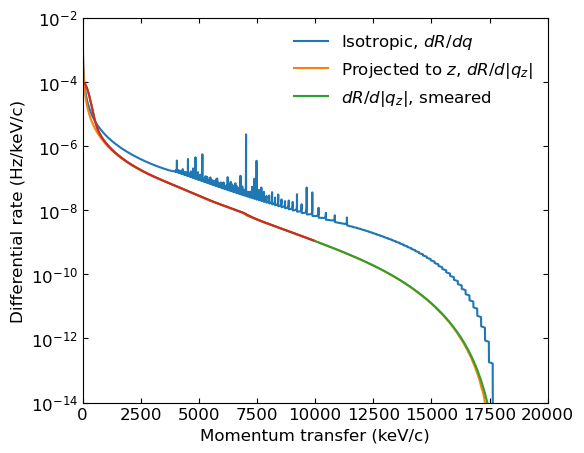

In [29]:
print(np.trapz(drdq, qq))
print(np.trapz(drdqz, qq))

plt.plot(qq, drdq, label='Isotropic, $dR/dq$')
plt.plot(qq, drdqz, label='Projected to $z$, $dR/d|q_z|$')
plt.plot(qq, drdqz_smeared, label='$dR/d|q_z|$, smeared')
plt.plot(bc, drdqz_smeared_resampled)

plt.yscale('log')

plt.legend(frameon=False)
plt.xlabel('Momentum transfer (keV/c)', fontsize=12)
plt.ylabel('Differential rate (Hz/keV/c)', fontsize=12)

plt.ylim(1e-14, 1e-2)
plt.xlim(0, 20000)

In [32]:
qmax = max(50 * (_qq[np.nonzero(_drdq_smoothed > 0)[0][-1]] // 50 + 2), 10000)
bins_sample = np.arange(0, qmax, 50)
bc = 0.5 * (bins_sample[1:] + bins_sample[:-1])

n_mc = int(1e8)
sigma_gaus = 180
rng = np.random.default_rng()

rr = rng.uniform(0, 1, n_mc)
uu = rng.uniform(-1, 1, n_mc)
phiphi = rng.uniform(0, 2*np.pi, n_mc)
noise_gaussian = rng.normal(0, sigma_gaus, n_mc)

qq_sampled, norm = get_random_q_samples(qq, drdq, rr)

hh, be   = np.histogram(np.abs(qq_sampled), bins=np.arange(0, qmax, 50), density=True)
hhx, be  = np.histogram(np.abs(qq_sampled * np.sqrt(1 - uu**2) * np.cos(phiphi)), bins=np.arange(0, qmax, 50), density=True)
hhy, be  = np.histogram(np.abs(qq_sampled * np.sqrt(1 - uu**2) * np.sin(phiphi)), bins=np.arange(0, qmax, 50), density=True)
hhz, be  = np.histogram(np.abs(qq_sampled * uu), bins=np.arange(0, qmax, 50), density=True)
hhzn, be = np.histogram(np.abs(qq_sampled * uu + noise_gaussian), bins=bins_sample, density=True)


(1e-10, 0.001)

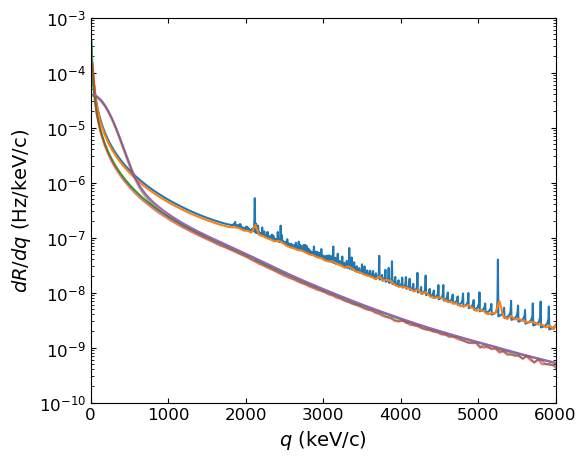

In [126]:
bc = 0.5 * (bins_sample[1:] + bins_sample[:-1])

plt.plot(qq, drdq)
plt.plot(bc, hh*norm)

plt.plot(qq, drdqz)
# plt.plot(bc, hhx*norm, alpha=0.4)
# plt.plot(bc, hhy*norm, alpha=0.4)
plt.plot(bc, hhz*norm, alpha=0.6)

plt.plot(qq, drdqz_smeared)
plt.plot(bc, hhzn*norm, alpha=0.6)

plt.yscale('log')
plt.xlabel('$q$ (keV/c)')
plt.ylabel('$dR/dq$ (Hz/keV/c)')

plt.xlim(0, 6000)
plt.ylim(1e-10, 1e-3)


In [75]:
file = f'{data_dir}/drdqz_all_coarse_nanosphere_{R_um:.2e}_{mphi:.0e}.npz'
drdqz_npz = np.load(file)

In [88]:
bc = drdqz_npz['bc_kev']
drdqzn = drdqz_npz['drdqzn']

In [96]:
drdqzn[0].shape

(79, 199)

In [101]:
[[drdqzn[0, j]] for j in range(drdqzn[0].shape[0])]

[array([2.66663663e-03, 2.51066400e-03, 2.19459834e-03, 1.78116800e-03,
        1.34247043e-03, 9.39828713e-04, 6.11310789e-04, 3.69577768e-04,
        2.07769960e-04, 1.08678629e-04, 5.29295131e-05, 2.40225358e-05,
        1.01707400e-05, 4.02183824e-06, 1.48745529e-06, 5.15346087e-07,
        1.67549897e-07, 5.12112008e-08, 1.47372765e-08, 3.97675731e-09,
        8.05295658e-10, 1.69599518e-10, 3.51317292e-11, 6.50489045e-12,
        9.83793390e-13, 9.98590311e-14, 3.28850632e-15, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

In [89]:
bc

array([  25.,   75.,  125.,  175.,  225.,  275.,  325.,  375.,  425.,
        475.,  525.,  575.,  625.,  675.,  725.,  775.,  825.,  875.,
        925.,  975., 1025., 1075., 1125., 1175., 1225., 1275., 1325.,
       1375., 1425., 1475., 1525., 1575., 1625., 1675., 1725., 1775.,
       1825., 1875., 1925., 1975., 2025., 2075., 2125., 2175., 2225.,
       2275., 2325., 2375., 2425., 2475., 2525., 2575., 2625., 2675.,
       2725., 2775., 2825., 2875., 2925., 2975., 3025., 3075., 3125.,
       3175., 3225., 3275., 3325., 3375., 3425., 3475., 3525., 3575.,
       3625., 3675., 3725., 3775., 3825., 3875., 3925., 3975., 4025.,
       4075., 4125., 4175., 4225., 4275., 4325., 4375., 4425., 4475.,
       4525., 4575., 4625., 4675., 4725., 4775., 4825., 4875., 4925.,
       4975., 5025., 5075., 5125., 5175., 5225., 5275., 5325., 5375.,
       5425., 5475., 5525., 5575., 5625., 5675., 5725., 5775., 5825.,
       5875., 5925., 5975., 6025., 6075., 6125., 6175., 6225., 6275.,
       6325., 6375.,

(1e-10, 0.01)

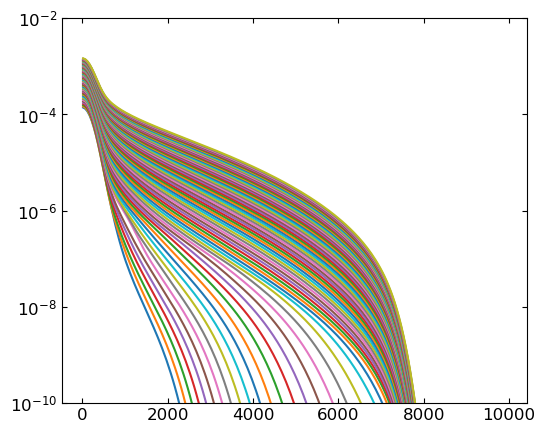

In [86]:
for i in range(79):
    plt.plot(bc, drdqzn[20][i])

plt.yscale('log')
plt.ylim(1e-10, 1e-2)

In [43]:
pls = np.empty((mx_list_coarse.size, alpha_list_coarse.size))
for i, mx in enumerate(mx_list_coarse):
    print(i)
    for j, alpha in enumerate(alpha_list_coarse):
        file = f'{data_dir}/drdq_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'

        drdq_npz = np.load(file)
        qq = drdq_npz['q_kev']

        dq = qq[1] - qq[0]
        qq_gauss = np.arange(-1000, 1000, dq)

        pls[i, j] = qq_gauss.size

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76


In [58]:
pls[76]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [68]:
mx, alpha = mx_list_coarse[76], alpha_list_coarse[-1]

file = f'{data_dir}/drdq_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'

drdq_npz = np.load(file)
qq = drdq_npz['q_kev']
drdq = drdq_npz['drdq_hz_kev']

(0.0, 20000.0)

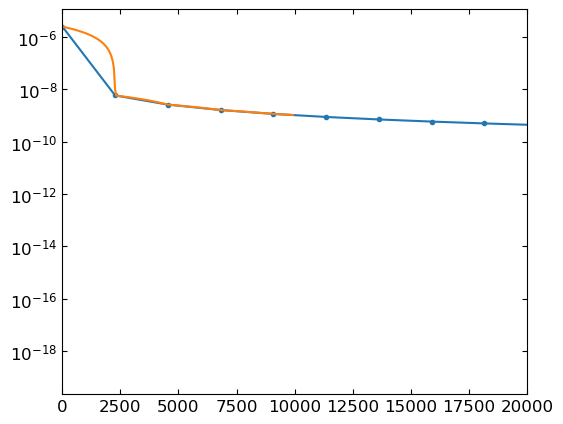

In [72]:
plt.plot(qq, drdq, '.-')
plt.plot(bc, np.interp(bc, qq, drdq))
plt.yscale('log')

plt.xlim(0, 20000)


In [30]:
npz = np.load('/home/yt388/palmer_scratch/data/dm_rate/mphi_1e+00/drdqz_all_nanosphere_8.30e-02_1e+00.npz')

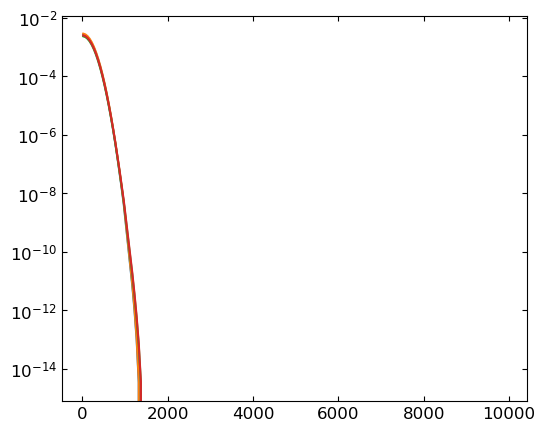

In [38]:
for i in range(2):
    for j in range(2):
        plt.plot(npz['bc_kev'], npz['drdqzn'][i, j])
plt.yscale('log')

In [39]:
npz.close()